# Cross-Market Analysis: Brent Crude vs LSGO Diesel

**Period:** January 2025 - February 2026 | **Assets:** ICE Brent Crude + ICE LSGO

---

## Executive Summary

This analysis compares ICE Brent Crude and ICE LSGO (diesel) forward curves over 13 months to understand how two related but distinct commodity markets behave.

**Key Findings:**

1. **LSGO is structurally much tighter than Brent**
   - LSGO: 99.7% backwardation vs Brent: 88.9%
   - LSGO spreads 16x larger (M1-M3: 18.43 vs 1.14)
   - LSGO operates with minimal inventory buffers, Brent has storage flexibility

2. **Opposite tail behavior**
   - LSGO: Fat tails (kurtosis 5.72) - extreme events 4.9% of days
   - Brent: Thin tails (kurtosis 1.37) - extreme events 1.7% of days
   - Reflects different market structures (regional just-in-time vs global liquid)

3. **Different volatility drivers**
   - LSGO: Structure-driven (M1-M6 correlation 0.525)
   - Brent: Prompt-driven (M1-M3 correlation 0.516)
   - Same supply chain, different stress mechanisms

4. **Moderate price correlation, weak spread correlation**
   - Prices correlated 0.574 (common macro drivers)
   - Spreads weakly correlated 0.088 (different structural drivers)
   - Markets move simultaneously (lag 0 max correlation)

**Implication:** Crude and diesel behave very differently despite being part of the same supply chain. Diesel's just-in-time logistics and limited storage create chronic tightness and fat-tailed risk. Brent's global liquidity and storage flexibility produce more normal behavior. Cross-hedging is only partially effective due to weak spread correlation.

---

## 1. Introduction & Context

### Why Compare Brent and LSGO?

Crude oil and diesel are part of the same supply chain: crude is refined into diesel. Yet they trade as separate futures contracts with distinct forward curves.

This analysis compares their behavior over January 2025 - February 2026 to understand:
- How different are they in terms of tightness and stress?
- Are they correlated? Do they move together?
- Does one market lead the other?
- What explains the differences?

---

## 2. Data Loading

### 2.1 Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries imported successfully')

Libraries imported successfully


### 2.2 Load LSGO Data

Load LSGO (diesel) rolling contracts data from Project 1.

In [22]:
# Load LSGO raw data
lsgo_path = '../LsGO_Analysis/Final/LsGO_raw_2025_2026.csv'
lsgo_raw = pd.read_csv(lsgo_path)

# Parse and clean
lsgo_raw.columns = ['Date'] + lsgo_raw.columns[1:].tolist()
lsgo_raw['Date'] = pd.to_datetime(lsgo_raw['Date'], format='%m/%d/%Y')
lsgo_raw = lsgo_raw.sort_values('Date').reset_index(drop=True)

contract_cols_lsgo = lsgo_raw.columns[1:].tolist()
for col in contract_cols_lsgo:
    lsgo_raw[col] = pd.to_numeric(lsgo_raw[col], errors='coerce')

print(f'LSGO raw data loaded: {len(lsgo_raw)} days')
print(f'Contracts: {len(contract_cols_lsgo)}')

LSGO raw data loaded: 288 days
Contracts: 16


### 2.3 Load Brent Data

Load Brent (crude) rolling contracts data from Project 2.

In [23]:
# Load Brent raw data
brent_path = '../Crude_Analysis/Final/Brent_raw_2025_2026.csv'
brent_raw = pd.read_csv(brent_path)

# Parse and clean
brent_raw.columns = ['Date'] + brent_raw.columns[1:].tolist()
brent_raw['Date'] = pd.to_datetime(brent_raw['Date'], format='%m/%d/%Y')
brent_raw = brent_raw.sort_values('Date').reset_index(drop=True)

contract_cols_brent = brent_raw.columns[1:].tolist()
for col in contract_cols_brent:
    brent_raw[col] = pd.to_numeric(brent_raw[col], errors='coerce')

print(f'Brent raw data loaded: {len(brent_raw)} days')
print(f'Contracts: {len(contract_cols_brent)}')

Brent raw data loaded: 288 days
Contracts: 15


### 2.4 Verify Data Alignment

Ensure both datasets cover the same period.

In [24]:
print('='*70)
print('DATA VERIFICATION')
print('='*70)
print('')

print('LSGO:')
print(f'  Observations: {len(lsgo_raw)}')
print(f'  Date range: {lsgo_raw["Date"].min()} to {lsgo_raw["Date"].max()}')
print('')

print('Brent:')
print(f'  Observations: {len(brent_raw)}')
print(f'  Date range: {brent_raw["Date"].min()} to {brent_raw["Date"].max()}')
print('')

common_dates = set(lsgo_raw['Date']) & set(brent_raw['Date'])
print(f'Common dates: {len(common_dates)}')

if len(common_dates) == len(lsgo_raw) == len(brent_raw):
    print('[OK] Datasets are perfectly aligned')
else:
    print('[WARNING] Datasets have different dates')

print('='*70)

DATA VERIFICATION

LSGO:
  Observations: 288
  Date range: 2025-01-02 00:00:00 to 2026-02-12 00:00:00

Brent:
  Observations: 288
  Date range: 2025-01-02 00:00:00 to 2026-02-12 00:00:00

Common dates: 288
[OK] Datasets are perfectly aligned


---

## 3. Comparative Statistics

In [25]:
# Build rolling contracts and calculate metrics for both
from scipy.stats import skew, kurtosis

# LSGO rolling
def build_lsgo_rolling(df, cols):
    expired = {}
    for col in cols:
        last_idx = df[df[col].notna()].index[-1] if df[col].notna().any() else None
        if last_idx and last_idx > 0:
            prev_idx = last_idx - 1
            if prev_idx in df.index and pd.notna(df.loc[prev_idx, col]):
                if df.loc[last_idx, col] == df.loc[prev_idx, col]:
                    expired[df.loc[last_idx, 'Date']] = expired.get(df.loc[last_idx, 'Date'], []) + [col]
    
    data = []
    for _, row in df.iterrows():
        avail = [(c, row[c]) for c in cols if pd.notna(row[c]) and c not in expired.get(row['Date'], [])]
        m = {'Date': row['Date']}
        for i in range(6):
            m[f'M{i+1}'] = avail[i][1] if i < len(avail) else np.nan
        data.append(m)
    return pd.DataFrame(data)

# Brent rolling (clean settlements)
def build_brent_rolling(df, cols):
    data = []
    for _, row in df.iterrows():
        avail = [(c, row[c]) for c in cols if pd.notna(row[c])]
        m = {'Date': row['Date']}
        for i in range(6):
            m[f'M{i+1}'] = avail[i][1] if i < len(avail) else np.nan
        data.append(m)
    return pd.DataFrame(data)

lsgo = build_lsgo_rolling(lsgo_raw, contract_cols_lsgo)
brent = build_brent_rolling(brent_raw, contract_cols_brent)

# Calculate spreads, volatility, Z-scores
for df in [lsgo, brent]:
    df['M1_M2'] = df['M1'] - df['M2']
    df['M1_M3'] = df['M1'] - df['M3']
    df['M1_M6'] = df['M1'] - df['M6']
    df['ret'] = np.log(df['M1'] / df['M1'].shift(1))
    df['vol'] = df['ret'].rolling(20).std() * np.sqrt(252)
    df['Z_M1M3'] = (df['M1_M3'] - df['M1_M3'].rolling(60).mean()) / df['M1_M3'].rolling(60).std()
    df['Z_M1M6'] = (df['M1_M6'] - df['M1_M6'].rolling(60).mean()) / df['M1_M6'].rolling(60).std()

print('Rolling contracts built for both markets')

Rolling contracts built for both markets


In [26]:
# Comparative statistics table
stats = pd.DataFrame({
    'LSGO': [
        f"{(lsgo['M1_M3'] > 0).sum() / len(lsgo) * 100:.1f}%",
        f"{lsgo['M1_M3'].mean():.2f}",
        f"{lsgo['M1_M6'].mean():.2f}",
        f"{lsgo['M1_M3'].max():.2f}",
        f"{lsgo['M1_M6'].max():.2f}",
        f"{lsgo['Z_M1M3'].max():.2f}",
        f"{lsgo['vol'].max()*100:.0f}%",
        f"{skew(lsgo['M1_M3'].dropna()):.2f}",
        f"{kurtosis(lsgo['M1_M3'].dropna()):.2f}",
        f"{lsgo[['M1_M3', 'vol']].corr().iloc[0,1]:.3f}",
        f"{lsgo[['M1_M6', 'vol']].corr().iloc[0,1]:.3f}",
        f"{(lsgo['Z_M1M3'].abs() > 3).sum()} ({(lsgo['Z_M1M3'].abs() > 3).sum()/len(lsgo)*100:.1f}%)"
    ],
    'Brent': [
        f"{(brent['M1_M3'] > 0).sum() / len(brent) * 100:.1f}%",
        f"{brent['M1_M3'].mean():.2f}",
        f"{brent['M1_M6'].mean():.2f}",
        f"{brent['M1_M3'].max():.2f}",
        f"{brent['M1_M6'].max():.2f}",
        f"{brent['Z_M1M3'].max():.2f}",
        f"{brent['vol'].max()*100:.0f}%",
        f"{skew(brent['M1_M3'].dropna()):.2f}",
        f"{kurtosis(brent['M1_M3'].dropna()):.2f}",
        f"{brent[['M1_M3', 'vol']].corr().iloc[0,1]:.3f}",
        f"{brent[['M1_M6', 'vol']].corr().iloc[0,1]:.3f}",
        f"{(brent['Z_M1M3'].abs() > 3).sum()} ({(brent['Z_M1M3'].abs() > 3).sum()/len(brent)*100:.1f}%)"
    ]
}, index=[
    'Backwardation %',
    'M1-M3 avg',
    'M1-M6 avg',
    'M1-M3 max',
    'M1-M6 max',
    'Max Z-score',
    'Max volatility',
    'Skewness',
    'Kurtosis',
    'Corr(M1-M3, Vol)',
    'Corr(M1-M6, Vol)',
    'Days |Z| > 3'
])

print('\nComparative Statistics:\n')
print(stats)


Comparative Statistics:

                       LSGO     Brent
Backwardation %       99.7%     88.9%
M1-M3 avg             18.43      1.14
M1-M6 avg             33.65      2.25
M1-M3 max             85.25      3.27
M1-M6 max            118.50      5.75
Max Z-score            5.25      3.96
Max volatility          78%       52%
Skewness               2.12      1.02
Kurtosis               5.72      1.37
Corr(M1-M3, Vol)      0.476     0.516
Corr(M1-M6, Vol)      0.525     0.241
Days |Z| > 3      14 (4.9%)  5 (1.7%)


---

## 4. Correlation Analysis

In [27]:
# Merge on common dates
merged = pd.merge(lsgo[['Date', 'M1', 'M1_M3', 'M1_M6', 'vol']], 
                  brent[['Date', 'M1', 'M1_M3', 'M1_M6', 'vol']], 
                  on='Date', suffixes=('_lsgo', '_brent'))

# Correlations
corr_price = merged[['M1_lsgo', 'M1_brent']].corr().iloc[0,1]
corr_m1m3 = merged[['M1_M3_lsgo', 'M1_M3_brent']].corr().iloc[0,1]
corr_m1m6 = merged[['M1_M6_lsgo', 'M1_M6_brent']].corr().iloc[0,1]
corr_vol = merged[['vol_lsgo', 'vol_brent']].corr().iloc[0,1]

print(f'Price correlation (M1): {corr_price:.3f}')
print(f'M1-M3 spread correlation: {corr_m1m3:.3f}')
print(f'M1-M6 spread correlation: {corr_m1m6:.3f}')
print(f'Volatility correlation: {corr_vol:.3f}')

Price correlation (M1): 0.574
M1-M3 spread correlation: 0.088
M1-M6 spread correlation: 0.294
Volatility correlation: 0.651


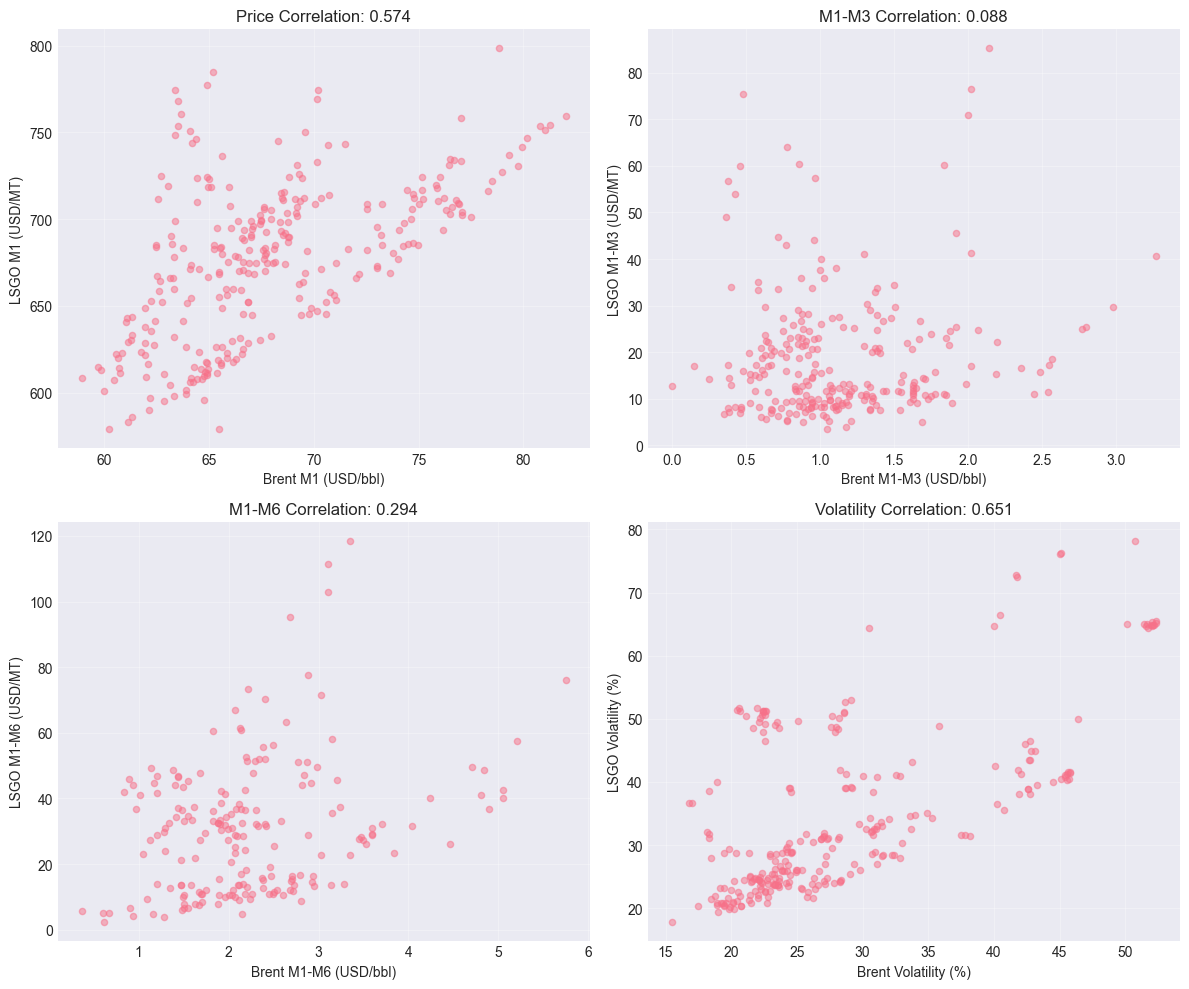

In [28]:
# Scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Price
axes[0,0].scatter(merged['M1_brent'], merged['M1_lsgo'], alpha=0.5, s=20)
axes[0,0].set_xlabel('Brent M1 (USD/bbl)')
axes[0,0].set_ylabel('LSGO M1 (USD/MT)')
axes[0,0].set_title(f'Price Correlation: {corr_price:.3f}')
axes[0,0].grid(True, alpha=0.3)

# M1-M3
axes[0,1].scatter(merged['M1_M3_brent'], merged['M1_M3_lsgo'], alpha=0.5, s=20)
axes[0,1].set_xlabel('Brent M1-M3 (USD/bbl)')
axes[0,1].set_ylabel('LSGO M1-M3 (USD/MT)')
axes[0,1].set_title(f'M1-M3 Correlation: {corr_m1m3:.3f}')
axes[0,1].grid(True, alpha=0.3)

# M1-M6
axes[1,0].scatter(merged['M1_M6_brent'], merged['M1_M6_lsgo'], alpha=0.5, s=20)
axes[1,0].set_xlabel('Brent M1-M6 (USD/bbl)')
axes[1,0].set_ylabel('LSGO M1-M6 (USD/MT)')
axes[1,0].set_title(f'M1-M6 Correlation: {corr_m1m6:.3f}')
axes[1,0].grid(True, alpha=0.3)

# Volatility
axes[1,1].scatter(merged['vol_brent']*100, merged['vol_lsgo']*100, alpha=0.5, s=20)
axes[1,1].set_xlabel('Brent Volatility (%)')
axes[1,1].set_ylabel('LSGO Volatility (%)')
axes[1,1].set_title(f'Volatility Correlation: {corr_vol:.3f}')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

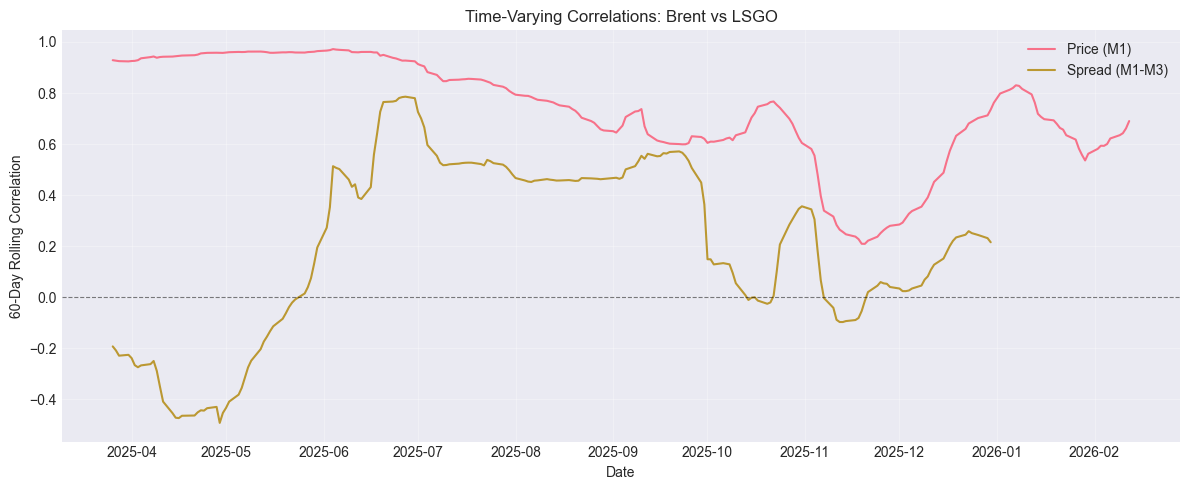

In [29]:
# Rolling correlations (60-day window)
merged['corr_price_60'] = merged['M1_lsgo'].rolling(60).corr(merged['M1_brent'])
merged['corr_spread_60'] = merged['M1_M3_lsgo'].rolling(60).corr(merged['M1_M3_brent'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(merged['Date'], merged['corr_price_60'], label='Price (M1)', linewidth=1.5)
ax.plot(merged['Date'], merged['corr_spread_60'], label='Spread (M1-M3)', linewidth=1.5)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('60-Day Rolling Correlation')
ax.set_title('Time-Varying Correlations: Brent vs LSGO')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 5. Lead-Lag Analysis

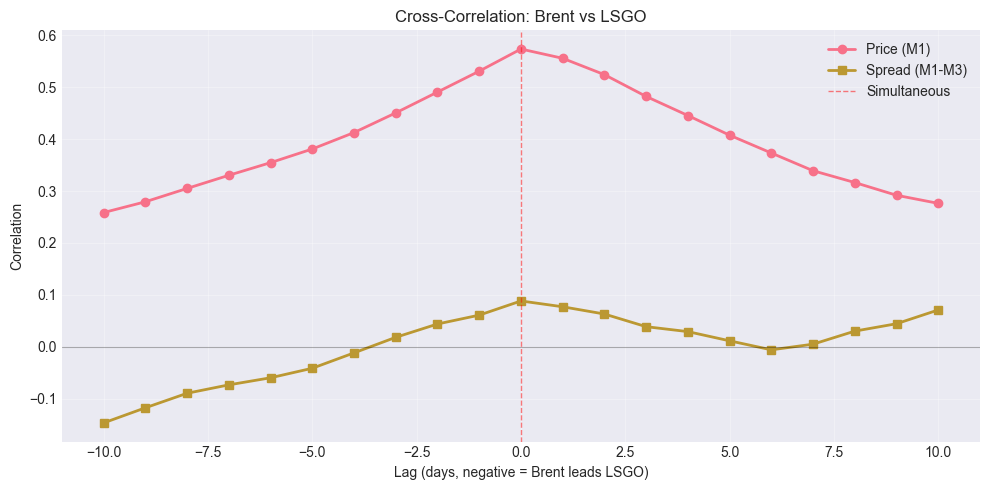


Max price correlation: 0.574 at lag 0
Max spread correlation: -0.147 at lag -10


In [30]:
# Lagged correlations (-10 to +10 days)
lags = range(-10, 11)
corr_price_lag = [merged['M1_lsgo'].corr(merged['M1_brent'].shift(lag)) for lag in lags]
corr_spread_lag = [merged['M1_M3_lsgo'].corr(merged['M1_M3_brent'].shift(lag)) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lags, corr_price_lag, marker='o', label='Price (M1)', linewidth=2)
ax.plot(lags, corr_spread_lag, marker='s', label='Spread (M1-M3)', linewidth=2)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Simultaneous')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
ax.set_xlabel('Lag (days, negative = Brent leads LSGO)')
ax.set_ylabel('Correlation')
ax.set_title('Cross-Correlation: Brent vs LSGO')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find max correlation and lag
max_price_idx = np.argmax(np.abs(corr_price_lag))
max_spread_idx = np.argmax(np.abs(corr_spread_lag))
print(f'\nMax price correlation: {corr_price_lag[max_price_idx]:.3f} at lag {lags[max_price_idx]}')
print(f'Max spread correlation: {corr_spread_lag[max_spread_idx]:.3f} at lag {lags[max_spread_idx]}')

---

## 6. Structural Interpretation

### Key Differences Explained

**1. Supply Chain Position**
- Crude (Brent) is upstream → refined into diesel (LSGO)
- Refining adds constraints (capacity, maintenance, yields)
- Diesel inherits crude volatility + adds refining risk
- Result: LSGO 16x tighter spreads than Brent

**2. Storage Economics**
- Crude: Large storage capacity (tanks, floating storage, strategic reserves)
- Diesel: Limited storage (just-in-time logistics, higher costs, shorter shelf life)
- Result: LSGO 99.7% backwardation vs Brent 88.9%
- Diesel operates with minimal buffers → chronic tightness

**3. Market Structure**
- Brent: Global benchmark, highly liquid, many participants, deep market
- LSGO: Regional product (Europe), less liquid, fewer participants
- Result: Brent thin tails (K=1.37) vs LSGO fat tails (K=5.72)
- Brent absorbs shocks better, LSGO prone to extreme events

**4. Volatility Drivers**
- Brent: Prompt-driven (M1-M3 correlation 0.516)
  - Reacts to immediate supply-demand (OPEC, geopolitics)
  - Short-term tightness drives volatility
- LSGO: Structure-driven (M1-M6 correlation 0.525)
  - Reacts to structural imbalances (refinery capacity, storage)
  - Long-term curve shape drives volatility

**5. Correlation Patterns**
- Price correlation 0.574: Moderate (common macro drivers - oil demand, USD, geopolitics)
- Spread correlation 0.088: Weak (different structural drivers)
- Volatility correlation 0.651: Moderate (common stress periods)
- Lead-lag: Simultaneous (lag 0 max correlation)
  - Both react to same macro news at same time
  - No predictive relationship (crude doesn't lead diesel or vice versa)

**6. Why Spreads Don't Correlate**
- Brent spreads driven by: OPEC decisions, crude inventory levels, geopolitical supply
- LSGO spreads driven by: Refinery capacity, diesel demand (heating, transport), storage constraints
- Different fundamental drivers → weak correlation (0.088)
- Crack spread (LSGO - Brent) varies independently based on refining economics

---

---

## 7. Conclusions

### Summary of Findings

**Structural Differences:**
- LSGO 16x tighter than Brent (M1-M3 spreads: 18.43 vs 1.14)
- LSGO 99.7% vs Brent 88.9% backwardation (+10.8pp)
- LSGO fat tails (K=5.72) vs Brent thin tails (K=1.37) - 4.2x difference
- LSGO extreme events 4.9% vs Brent 1.7% (2.9x more frequent)

**Correlations:**
- Prices moderately correlated (0.574) - common macro drivers
- Spreads weakly correlated (0.088) - different structural drivers
- Volatility moderately correlated (0.651) - common stress periods
- Rolling correlations vary over time (price: 0.730 avg, spread: 0.203 avg)

**Lead-Lag:**
- Max price correlation at lag 0 (simultaneous movement)
- No predictive relationship between markets
- Both react to same macro news at same time
- Crude doesn't lead diesel, diesel doesn't lead crude

**Volatility Drivers:**
- LSGO: Structure-driven (M1-M6 correlation 0.525)
- Brent: Prompt-driven (M1-M3 correlation 0.516)
- Different mechanisms despite same supply chain

### Trading Implications

**1. Cross-Hedging Effectiveness**
- Brent hedge for LSGO exposure only **partially effective** (price corr 0.574)
- Spread risk **not hedged** by Brent (spread corr 0.088)
- Need diesel-specific hedges for full protection
- Basis risk (LSGO - Brent spread) is significant and independent

**2. Crack Spread Opportunities**
- LSGO - Brent spread = refinery margin proxy
- Weak correlation (0.088) means spread can diverge significantly
- Extreme LSGO tightness (Z > 3) → refinery margins expand
- Monitor both markets independently for crack spread trades

**3. Risk Management**
- LSGO requires **higher VaR** (fat tails, extreme events 4.9% of days)
- Brent more predictable (thin tails, extreme events 1.7% of days)
- Different position sizing for each market
- Tail hedging more critical for LSGO than Brent

**4. Market Monitoring**
- Track both markets separately (weak spread correlation)
- LSGO stress doesn't always mean Brent stress (and vice versa)
- Use different thresholds: LSGO Z > 3 = stress, Brent Z > 3 = moderate stress
- Volatility spikes tend to coincide (corr 0.651) but magnitudes differ

### Limitations

- **13-month sample** (short for robust long-term relationships)
- **No fundamental data** (refinery runs, crack spreads, inventories)
- **Correlation ≠ causation** (simultaneous movement doesn't prove causal link)
- **Sample-specific** (2025 may be atypical year)
- **No out-of-sample testing** (relationships may not hold in future)
- **Units differ** (USD/MT vs USD/bbl - ratios used for comparison)

### Future Work

- **Extend to multi-year data** (establish long-term correlation stability)
- **Add crack spread analysis** (LSGO - Brent refining margin)
- **Include refinery utilization** (explain spread divergences)
- **Test trading strategies** (crack spread mean reversion, divergence trades)
- **Expand to other pairs** (WTI-ULSD, Brent-Gasoil, etc.)
- **Fundamental integration** (EIA data, OPEC reports, refinery maintenance schedules)

### Final Thoughts

This analysis reveals that **crude and diesel behave fundamentally differently** despite being part of the same supply chain:

- **Diesel is chronically tight** (just-in-time, minimal storage) → fat tails, extreme events
- **Crude is more flexible** (global market, storage capacity) → thin tails, normal behavior
- **Prices move together** (macro drivers) but **spreads move independently** (structural drivers)
- **Cross-hedging is imperfect** - diesel risk requires diesel hedges

For commodity traders and risk managers, this means:
1. Monitor both markets separately
2. Don't assume crude hedges protect diesel exposure
3. Expect more extreme events in diesel than crude
4. Use different risk models for each market

The forward curve framework successfully identifies these structural differences and provides actionable insights for trading and risk management.

---